--- 1. ANALISI STATICITÀ (Effetto Gradino) ---
Il 3.65% delle righe ha lo stesso identico livello di NO2 dell'ora precedente.
✅ Buono: I dati sembrano variare ora per ora.

--- 2. BILANCIAMENTO CLASSI (Class_Inc_NO2) ---
Class_Inc_NO2
Forte Calo       3322
Forte Aumento    3322
Calo Lieve       3321
Aumento Lieve    3321
Name: count, dtype: int64


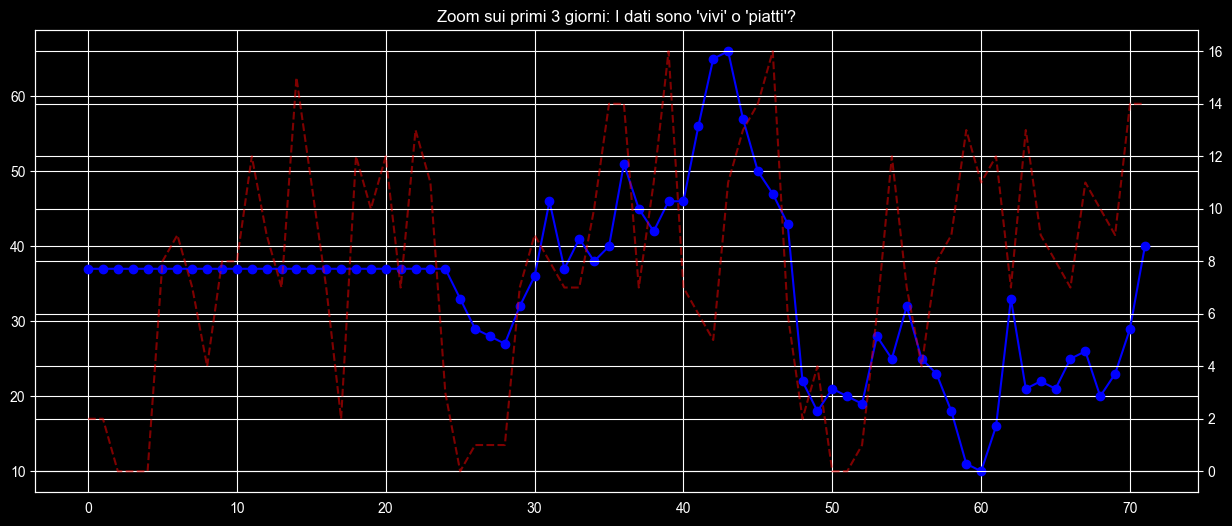

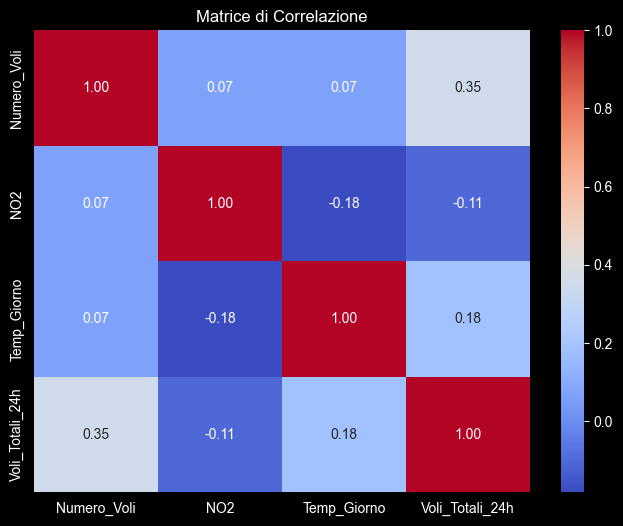

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento
df = pd.read_excel("Dataset_READY_FOR_AI.xlsx")
NOME_INQUINANTE = 'NO2' # L'inquinante che stiamo studiando

# 1. CONTROLLO "VALORI CONGELATI" (Staticità)
# Contiamo quante volte il valore cambia rispetto all'ora prima
df['NO2_Diff'] = df['NO2'].diff()
perc_statici = (df['NO2_Diff'] == 0).sum() / len(df) * 100

print(f"--- 1. ANALISI STATICITÀ (Effetto Gradino) ---")
print(f"Il {perc_statici:.2f}% delle righe ha lo stesso identico livello di NO2 dell'ora precedente.")
if perc_statici > 50:
    print("⚠️ ALLARME: Sembra che i dati degli inquinanti siano spesso giornalieri (ripetuti) e non orari.")
    print("   L'IA farà fatica a trovare correlazioni orarie precise.")
else:
    print("✅ Buono: I dati sembrano variare ora per ora.")

# 2. CONTROLLO SBILANCIAMENTO CLASSI
target_col = f'Class_Inc_{NOME_INQUINANTE}'
print(f"\n--- 2. BILANCIAMENTO CLASSI ({target_col}) ---")
counts = df[target_col].value_counts()
print(counts)
perc_minoritaria = counts.min() / len(df) * 100

if perc_minoritaria < 10:
    print(f"⚠️ ATTENZIONE: La classe '{counts.idxmin()}' è rarissima ({perc_minoritaria:.1f}%).")
    print("   L'IA potrebbe ignorarla completamente (Accuracy Paradox).")

# 3. VISUALIZZAZIONE "LA PROVA DEL NOVE"
# Prendiamo 3 giorni a caso e vediamo se la linea è piatta o si muove
subset = df.iloc[0:72] # Primi 3 giorni (24h * 3)

plt.figure(figsize=(15, 6))

# Asse Y1: Inquinante
plt.plot(subset.index, subset['NO2'], label='Livello NO2', marker='o', color='blue')

# Asse Y2: Voli (per vedere se si muovono insieme)
ax2 = plt.gca().twinx()
ax2.plot(subset.index, subset['Numero_Voli'], label='Numero Voli', color='red', linestyle='--', alpha=0.5)

plt.title("Zoom sui primi 3 giorni: I dati sono 'vivi' o 'piatti'?")
plt.show()

# 4. CORRELAZIONE MATEMATICA
features_check = ['Numero_Voli', 'NO2', 'Temp_Giorno', 'Voli_Totali_24h']
corr = df[features_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di Correlazione")
import pandas as pd
import numpy as np

# Carica il dataset
df = pd.read_excel("Dataset_READY_FOR_AI.xlsx")

# Converti data
if 'Ora' not in df.columns:
    df['Data'] = pd.to_datetime(df['Data'])
    df['Date_Only'] = df['Data'].dt.date

print("--- ANALISI FREQUENZA SENSORI ---\n")

colonne_da_analizzare = ['Numero_Voli', 'NO2', 'PM10', 'PM25', 'C6H6', 'CO'] # Aggiungi altri se ne hai

for col in colonne_da_analizzare:
    if col not in df.columns:
        continue

    # Calcoliamo la varianza INTRA-GIORNALIERA
    # Raggruppiamo per giorno e contiamo quanti valori unici ci sono in quel giorno
    # Se c'è solo 1 valore unico per tutto il giorno, è un dato giornaliero.

    daily_variance = df.groupby('Date_Only')[col].nunique()

    # Se la media dei valori unici per giorno è vicina a 1, è un dato giornaliero
    media_valori_unici = daily_variance.mean()

    print(f"📊 {col}: ", end="")

    if media_valori_unici < 1.1:
        print("🔴 GIORNALIERO (Dato statico ripetuto)")
    elif media_valori_unici < 5:
        print("🟠 MISTO/BASSA RISOLUZIONE (Cambia poche volte al giorno)")
    else:
        print("🟢 ORARIO (Dato ad alta frequenza)")

print("\n-------------------------------------------")plt.show()

In [3]:
import pandas as pd
import numpy as np

# Carica il dataset
df = pd.read_excel("Dataset_READY_FOR_AI.xlsx")

# Converti data
if 'Ora' not in df.columns:
    df['Data'] = pd.to_datetime(df['Data'])
    df['Date_Only'] = df['Data'].dt.date

print("--- ANALISI FREQUENZA SENSORI ---\n")

colonne_da_analizzare = ['Numero_Voli', 'NO2', 'PM10', 'PM25', 'C6H6', 'CO'] # Aggiungi altri se ne hai

for col in colonne_da_analizzare:
    if col not in df.columns:
        continue

    # Calcoliamo la varianza INTRA-GIORNALIERA
    # Raggruppiamo per giorno e contiamo quanti valori unici ci sono in quel giorno
    # Se c'è solo 1 valore unico per tutto il giorno, è un dato giornaliero.

    daily_variance = df.groupby('Date_Only')[col].nunique()

    # Se la media dei valori unici per giorno è vicina a 1, è un dato giornaliero
    media_valori_unici = daily_variance.mean()

    print(f"📊 {col}: ", end="")

    if media_valori_unici < 1.1:
        print("🔴 GIORNALIERO (Dato statico ripetuto)")
    elif media_valori_unici < 5:
        print("🟠 MISTO/BASSA RISOLUZIONE (Cambia poche volte al giorno)")
    else:
        print("🟢 ORARIO (Dato ad alta frequenza)")

print("\n-------------------------------------------")

--- ANALISI FREQUENZA SENSORI ---

📊 Numero_Voli: 🟢 ORARIO (Dato ad alta frequenza)
📊 NO2: 🟢 ORARIO (Dato ad alta frequenza)
📊 PM10: 🔴 GIORNALIERO (Dato statico ripetuto)
📊 PM25: 🟢 ORARIO (Dato ad alta frequenza)
📊 C6H6: 🟢 ORARIO (Dato ad alta frequenza)
📊 CO: 🟢 ORARIO (Dato ad alta frequenza)

-------------------------------------------
